In [1]:
# Imports
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np

# Change font to respect submission requirements
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = "Times New Roman"
plt.rcParams["font.size"] = 14
plt.rcParams["font.weight"] = "normal"

# srun -w mauao -c 5 --partition=interactive --pty bash
# srun -w ngongotaha -c 5 --partition=interactive --pty bash
# srun -w ruapehu -c 20 --partition=interactive --pty bash
# poetry shell
# jupyter server --no-browser --port=8889
# ssh -L 8889:localhost:8889 ls985@mauao
# ssh -L 8889:localhost:8889 ls985@ngongotaha
# ssh -L 8889:localhost:8890 ls985@ruapehu

In [2]:
def analyse_gpu_metrics(csv_file: Path) -> pd.DataFrame:
    """Analyse the GPU metrics from a .csv file and return a pandas DataFrame."""
    # Read the .csv file into a pandas DataFrame
    gpu_dataframe = pd.read_csv(
        csv_file,
        skipfooter=1,
        engine="python",
        header=None,
        names=[
            "timestamp",
            "name",
            "index",
            "pci.bus_id",
            "gpu_util",
            "mem_util",
            "mem_total",
            "mem_free",
            "mem_used",
        ],
    )
    # Drop the columns that are not needed
    gpu_dataframe = gpu_dataframe.drop(
        columns=["pci.bus_id", "mem_util", "mem_total", "mem_free"]
    )
    # Convert the `timestamp` column to datetime
    gpu_dataframe["timestamp"] = pd.to_datetime(gpu_dataframe["timestamp"])
    # Convert `timestamp` to seconds
    gpu_dataframe["timestamp"] = gpu_dataframe["timestamp"].astype(int) / 10**9
    # Filter-out rows where `mem_used` is lower than 100 (MB)
    gpu_dataframe = gpu_dataframe[gpu_dataframe["mem_used"] > 100]  # noqa: PLR2004
    gpu_dataframe = gpu_dataframe[
        gpu_dataframe["mem_used"] > gpu_dataframe["mem_used"].min()
    ]
    # Shift the timestamp to start from 0
    gpu_dataframe["timestamp"] = (
        gpu_dataframe["timestamp"] - gpu_dataframe["timestamp"].min()
    )
    # Filter out rows with a timestamp smaller than 50 seconds
    # gpu_dataframe = gpu_dataframe[gpu_dataframe["timestamp"] > 50]
    gpu_dataframe = gpu_dataframe[gpu_dataframe["timestamp"] > 75]
    # Filter out rows with a timestamp bigger than 150 seconds
    # gpu_dataframe = gpu_dataframe[gpu_dataframe["timestamp"] < 150]
    gpu_dataframe = gpu_dataframe[gpu_dataframe["timestamp"] < 125]
    # Rename colum `index` to `GPU Index`
    gpu_dataframe = gpu_dataframe.rename(columns={"index": "GPU Index"})
    # # Compute AUC for `gpu_util` and `mem_used` columns over `timestamp`
    # gpu_dataframe["gpu_util_auc"] = (
    #     np.trapz(gpu_dataframe["gpu_util"], gpu_dataframe["timestamp"])
    #     / gpu_dataframe["timestamp"].max()
    # )
    # gpu_dataframe["mem_used_frac_auc"] = (
    #     np.trapz(gpu_dataframe["mem_used_frac"], gpu_dataframe["timestamp"])
    #     / gpu_dataframe["timestamp"].max()
    # )
    return gpu_dataframe

[[<Axes: > <Axes: >]
 [<Axes: > <Axes: >]]


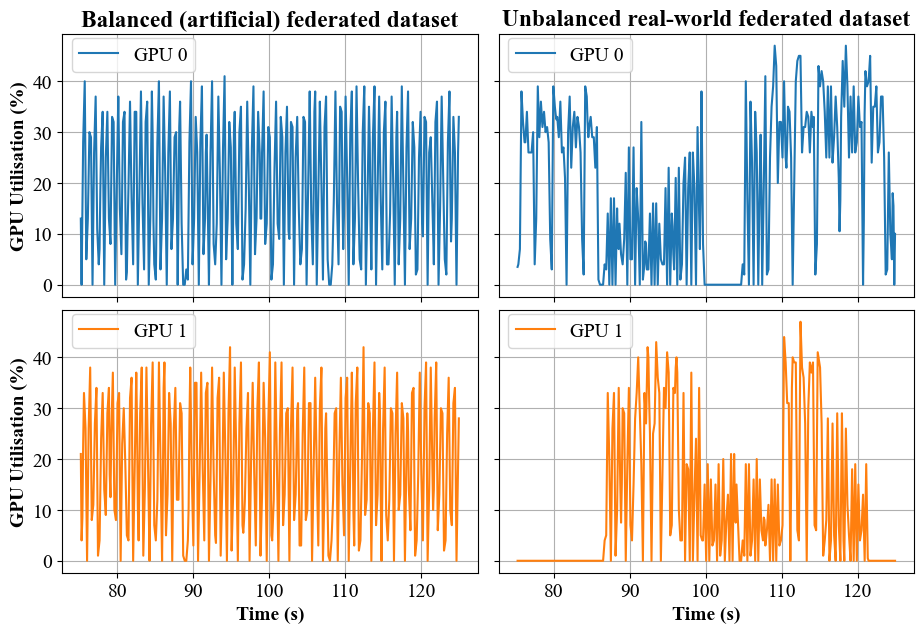

In [4]:
ROOT_PATH = "/nfs-share/ls985/projects/sosp-pollen_worker/"
dataframes: list[pd.DataFrame] = []
# Create a figure with two plots arranged horizontally
fig, ax = plt.subplots(2, 2, figsize=(11, 7), sharey=True, sharex=True)
print(ax)
# Add a big red oval to the first plot at the front
# ellipse_0 = mpatches.Ellipse(
#     (80, 20),
#     20,
#     40,
#     fill=False,
#     edgecolor="black",
#     linewidth=2,
#     linestyle="--",
# )
# rectangle_0 = mpatches.Rectangle(
#     (97, 0),
#     10,
#     25,
#     fill=False,
#     edgecolor="black",
#     linewidth=2,
#     linestyle="--",
# )
# ellipse_1 = mpatches.Ellipse(
#     (128, 20),
#     20,
#     40,
#     fill=False,
#     edgecolor="black",
#     linewidth=2,
#     linestyle="--",
# )
# ax[0][0].add_patch(ellipse_0)
# ax[0][0].add_patch(rectangle_0)
# ax[0][0].add_patch(ellipse_1)
colors = sns.color_palette("tab10", n_colors=2)
# Iterate over all the .csv files in the directory
for i, file in enumerate(Path(ROOT_PATH).glob("monitor*.csv")):
    # Read the .csv file into a pandas DataFrame
    gpu_dataframe = analyse_gpu_metrics(file)
    # Define the size of the rolling window
    window_size = 2
    # Apply the rolling mean to the 'gpu_util' column
    gpu_dataframe["gpu_util_smooth"] = gpu_dataframe.groupby("GPU Index")[
        "gpu_util"
    ].transform(lambda x: x.rolling(window_size).mean())
    for k, gpu_id in enumerate(gpu_dataframe["GPU Index"].unique()):
        single_gpu = gpu_dataframe[gpu_dataframe["GPU Index"] == gpu_id]
        # Select the current ax obj from the figure

        # Plot the `gpu_util` column against the `timestamp` column for each `index` in the DataFrame
        ax[k][i].plot(
            single_gpu["timestamp"],
            single_gpu["gpu_util_smooth"],
            # data=gpu_dataframe,
            # data=single_gpu,
            # ax=ax[i][k],
            # alpha=0.7,
            color=colors[k],
            label=f"GPU {gpu_id}",
        )
        ax[k][i].grid()
        ax[k][i].legend(loc="upper left", bbox_to_anchor=(0.0, 1.02))
        # if i == 0:
        #     # ax[k][i].legend(loc="upper left", bbox_to_anchor=(0.0, 1.02))
        #     # # Set the foreground color of the plot to be gray
        #     # ax[k][i].set_facecolor((0.8, 0.8, 0.8))
        #     pass
        # else:
        #     # Set the foreground color of the plot to be gray
        #     ax[k][i].set_facecolor((0.7, 0.7, 0.7))
        if k == 0:
            if i == 0:
                title = ax[k][i].set_title("Balanced (artificial) federated dataset")
                title.set_weight("bold")
            else:
                title = ax[k][i].set_title("Unbalanced real-world federated dataset")
                title.set_weight("bold")
        # # Dont show the legend for the second plot
        # if i != 0 or k != 0:
        #     print(i, k, ax)
        #     # ax[i][k].get_legend().remove()
# # Get the legend
# legend = ax[0][0].legend(loc='upper right')
# # Set the font weight of the title of the legend to 'bold'
# legend_title = legend.get_title()
# legend_title.set_weight('bold')
# # Set the font weight of the text in the legend to 'bold'
# for j, text in enumerate(legend.get_texts()):
#     text.set_weight('bold')
#     text.set_text(f"GPU {j}")
y_label = ax[0][0].set_ylabel("GPU Utilisation (%)")
y_label.set_weight("bold")
y_label = ax[1][0].set_ylabel("GPU Utilisation (%)")
y_label.set_weight("bold")
x_label = ax[1][0].set_xlabel("Time (s)")
x_label.set_weight("bold")
x_label = ax[1][1].set_xlabel("Time (s)")
x_label.set_weight("bold")
# Reduce the sapce between plots
plt.subplots_adjust(wspace=0.05, hspace=0.05)
# # Bring ellipses at the front
# ellipse_0.set_zorder(10)
# rectangle_0.set_zorder(10)
# ellipse_1.set_zorder(10)
# Save the plot
plt.savefig("gpu_idle_time.pdf", format="pdf", dpi=800, bbox_inches="tight")
# Show the plot
plt.show()

In [ ]:
def get_auc_utilization(csv_file: Path) -> tuple[list[float], list[float]]:
    """Analyse the GPU metrics from a .csv file and return a pandas DataFrame."""
    # Read the .csv file into a pandas DataFrame
    gpu_dataframe = pd.read_csv(
        csv_file,
        skipfooter=1,
        engine="python",
        header=None,
        names=[
            "timestamp",
            "name",
            "index",
            "pci.bus_id",
            "gpu_util",
            "mem_util",
            "mem_total",
            "mem_free",
            "mem_used",
        ],
    )
    # Drop the columns that are not needed
    gpu_dataframe = gpu_dataframe.drop(
        columns=["pci.bus_id", "mem_util", "mem_total", "mem_free"]
    )
    # Convert the `timestamp` column to datetime
    gpu_dataframe["timestamp"] = pd.to_datetime(gpu_dataframe["timestamp"])
    # Convert `timestamp` to seconds
    gpu_dataframe["timestamp"] = gpu_dataframe["timestamp"].astype(int) / 10**9
    # Filter-out rows where `mem_used` is lower than 100 (MB)
    gpu_dataframe = gpu_dataframe[gpu_dataframe["mem_used"] > 100]  # noqa: PLR2004
    gpu_dataframe = gpu_dataframe[
        gpu_dataframe["mem_used"] > gpu_dataframe["mem_used"].min()
    ]
    # Shift the timestamp to start from 0
    gpu_dataframe["timestamp"] = (
        gpu_dataframe["timestamp"] - gpu_dataframe["timestamp"].min()
    )
    # Filter out rows with a timestamp smaller than 50 seconds
    gpu_dataframe = gpu_dataframe[gpu_dataframe["timestamp"] > 50]
    # Filter out rows with a timestamp bigger than 150 seconds
    gpu_dataframe = gpu_dataframe[gpu_dataframe["timestamp"] < 150]
    # Rename colum `index` to `GPU Index`
    gpu_dataframe = gpu_dataframe.rename(columns={"index": "GPU Index"})
    gpu_util_gpus: list[float] = []
    total_idle_times: list[float] = []
    for gpu_id in gpu_dataframe["GPU Index"].unique():
        single_gpu_dataframe = gpu_dataframe[
            gpu_dataframe["GPU Index"] == gpu_id
        ].reindex()
        gpu_util = single_gpu_dataframe["gpu_util"]
        single_gpu_dataframe["timestamp"] = (
            single_gpu_dataframe["timestamp"] - single_gpu_dataframe["timestamp"].min()
        )
        single_gpu_dataframe["timestamp_diff"] = single_gpu_dataframe[
            "timestamp"
        ].diff()
        timestamp = single_gpu_dataframe["timestamp"]
        gpu_util_gpus.append(np.trapz(gpu_util, timestamp) / timestamp.max())
        # Get the difference between subsequent timestamps
        zero_util_single_gpu_dataframe = single_gpu_dataframe[
            single_gpu_dataframe["gpu_util"] <= 0
        ].reindex()
        zero_util_timestamp_diff = zero_util_single_gpu_dataframe["timestamp_diff"]
        total_idle_times.append(np.sum(zero_util_timestamp_diff))
    return gpu_util_gpus, total_idle_times

In [ ]:
ROOT_PATH = "/nfs-share/ls985/projects/sosp-pollen_worker/"
dataframes: list[pd.DataFrame] = []
for i, file in enumerate(Path(ROOT_PATH).glob("monitor*.csv")):
    # Read the .csv file into a pandas DataFrame
    print(get_auc_utilization(file))

([19.005928134096937, 19.01124076679514], [12.305999517440796, 12.630999565124512])
([19.753715548794652, 10.874274212452978], [16.52199959754944, 40.500999450683594])
